# Resting Membrane Potential Analysis Pipeline

This notebook provides a reproducible Python workflow for extracting resting membrane potential (RMP) values from current-clamp electrophysiological recordings exported from HEKA/PatchMaster ASCII files.

The pipeline includes:

- HEKA ASCII file import
- baseline-window selection
- RMP mean calculation
- RMP median calculation
- baseline noise estimation
- batch analysis of recordings
- export of analysis results tables
- representative quality-control visualization

Recording names and experimental conditions are anonymized in this public version to protect unpublished experimental details.

## Workflow Overview

1. Import libraries  
2. User settings  
3. HEKA ASCII loader  
4. RMP extraction algorithm  
5. Batch RMP analysis  
6. Export results  
7. Quality-control analysis  
8. Representative quality-control visualization  

In [1]:
# ========================================
# MASTER SETUP CELL
# Run this first
# ========================================

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Setup complete")

Mounted at /content/drive
Setup complete


In [2]:
# ============================================================
# USER SETTINGS
# ============================================================

# Path containing HEKA/PatchMaster ASCII files
BASE_PATH = "/content/drive/MyDrive/PatchClampData/Python2/"

# Recordings included in the public workflow
# These names are anonymized for GitHub.
# In a real analysis, replace these with the names of your exported .asc files.
FILE_LIST = [
    "recording_01.asc",
    "recording_02.asc",
    "recording_03.asc"
]

# Generic group name used in exported tables
CONDITION_NAME = "Example_Group"

# Baseline window used to calculate RMP
BASELINE_WINDOW_S = 5

# Plot settings
Y_MIN = -90
Y_MAX = 50

# Output file names
LONG_FORMAT_CSV_NAME = "rmp_long_format.csv"
GRAPHPAD_CSV_NAME = "graphpad_rmp_median_mV.csv"
GROUP_SUMMARY_CSV_NAME = "rmp_group_summary.csv"

print("User settings loaded")

User settings loaded


In [3]:
# ============================================================
# HEKA PATCHMASTER ASCII FILE IMPORT
# ============================================================

def load_heka_ascii_voltage(file_path):
    """
    Load a HEKA/PatchMaster ASCII file exported from current-clamp recordings.

    Expected columns include:
    - Index
    - Time[s]
    - V-mon[V]
    - Stimulus

    Returns
    -------
    data : pandas.DataFrame
        DataFrame containing:
        - Time_s
        - Voltage_mV
    """

    header_line = None

    with open(file_path, "r") as f:
        for line_number, line in enumerate(f):
            if line.strip().startswith('"Index"') or line.strip().startswith("Index"):
                header_line = line_number
                break

    if header_line is None:
        raise ValueError(f"HEKA header not found: {file_path}")

    data = pd.read_csv(
        file_path,
        sep=",",
        skiprows=header_line
    )

    data.columns = (
        data.columns
        .str.strip()
        .str.replace('"', "", regex=False)
    )

    time_col = next(col for col in data.columns if "Time[s]" in col)
    voltage_col = next(col for col in data.columns if "V-mon[V]" in col)

    data = data[[time_col, voltage_col]].copy()
    data.columns = ["Time_s", "Voltage_V"]

    data["Time_s"] = pd.to_numeric(data["Time_s"], errors="coerce")
    data["Voltage_V"] = pd.to_numeric(data["Voltage_V"], errors="coerce")

    data = data.dropna()

    # Convert voltage from V to mV
    data["Voltage_mV"] = data["Voltage_V"] * 1000

    return data[["Time_s", "Voltage_mV"]]

print("HEKA ASCII loader ready")

HEKA ASCII loader ready


In [4]:
# ============================================================
# RMP EXTRACTION ALGORITHM
# ============================================================

def extract_rmp(
    file_path,
    recording_name,
    condition_name=CONDITION_NAME,
    baseline_window_s=BASELINE_WINDOW_S,
    y_min=Y_MIN,
    y_max=Y_MAX,
    save_figure=False
):
    """
    Extract resting membrane potential from the first baseline window.

    Analysis workflow
    -----------------
    1. Import HEKA/PatchMaster ASCII recording
    2. Select the baseline window
    3. Calculate:
        - RMP mean in mV
        - RMP median in mV
        - baseline SD/noise in mV
    4. Generate a quality-control plot showing the baseline window

    Returns
    -------
    results : dict
        Summary of RMP analysis.
    """

    data = load_heka_ascii_voltage(file_path)

    time = data["Time_s"].values
    voltage = data["Voltage_mV"].values

    baseline_mask = (time >= 0) & (time <= baseline_window_s)
    baseline_voltage = voltage[baseline_mask]

    if len(baseline_voltage) < 10:
        raise ValueError("Baseline window is too short or empty.")

    rmp_mean_mV = np.mean(baseline_voltage)
    rmp_median_mV = np.median(baseline_voltage)
    baseline_sd_mV = np.std(baseline_voltage)

    results = {
        "recording_name": recording_name,
        "condition": condition_name,
        "baseline_window_s": baseline_window_s,
        "RMP_mean_mV": rmp_mean_mV,
        "RMP_median_mV": rmp_median_mV,
        "baseline_SD_mV": baseline_sd_mV
    }

    # Quality-control plot: first baseline window
    plt.figure(figsize=(10, 4), dpi=300)

    plt.plot(
        time,
        voltage,
        color="black",
        linewidth=0.8
    )

    plt.axvspan(
        0,
        baseline_window_s,
        color="gray",
        alpha=0.15,
        label="RMP window"
    )

    plt.axhline(
        rmp_mean_mV,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=f"RMP mean = {rmp_mean_mV:.2f} mV"
    )

    plt.axhline(
        rmp_median_mV,
        color="blue",
        linestyle=":",
        linewidth=1.2,
        label=f"RMP median = {rmp_median_mV:.2f} mV"
    )

    plt.xlim(0, baseline_window_s)
    plt.ylim(
        np.min(baseline_voltage) - 10,
        np.max(baseline_voltage) + 10
    )

    plt.xlabel("Time (s)", fontsize=14)
    plt.ylabel("Membrane Potential (mV)", fontsize=14)
    plt.title(f"{recording_name} - RMP Baseline Window", fontsize=14)

    plt.legend(frameon=False)
    plt.tight_layout()

    if save_figure:
        plt.savefig(
            f"{recording_name}_rmp_baseline_window.png",
            dpi=600,
            bbox_inches="tight"
        )

        plt.savefig(
            f"{recording_name}_rmp_baseline_window.svg",
            format="svg",
            bbox_inches="tight"
        )

    plt.show()

    return results

print("RMP extraction algorithm ready")

RMP extraction algorithm ready


In [5]:
# ============================================================
# BATCH RMP ANALYSIS
# ============================================================

results = []

for index, file_name in enumerate(FILE_LIST, start=1):

    file_path = os.path.join(BASE_PATH, file_name)

    # Public anonymized recording name
    recording_name = f"recording_{index:02d}"

    print("\n----------------------------------------")
    print(f"Analyzing: {recording_name}")
    print(f"Input file: {file_name}")

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        continue

    out = extract_rmp(
        file_path=file_path,
        recording_name=recording_name,
        condition_name=CONDITION_NAME,
        baseline_window_s=BASELINE_WINDOW_S,
        y_min=Y_MIN,
        y_max=Y_MAX,
        save_figure=False
    )

    results.append(out)

# Create summary table
rmp_df = pd.DataFrame(results)

if len(rmp_df) > 0:

    rmp_df["RMP_mean_mV"] = rmp_df["RMP_mean_mV"].round(2)
    rmp_df["RMP_median_mV"] = rmp_df["RMP_median_mV"].round(2)
    rmp_df["baseline_SD_mV"] = rmp_df["baseline_SD_mV"].round(2)

display(rmp_df)


----------------------------------------
Analyzing: recording_01
Input file: recording_01.asc
File not found: /content/drive/MyDrive/PatchClampData/Python2/recording_01.asc

----------------------------------------
Analyzing: recording_02
Input file: recording_02.asc
File not found: /content/drive/MyDrive/PatchClampData/Python2/recording_02.asc

----------------------------------------
Analyzing: recording_03
Input file: recording_03.asc
File not found: /content/drive/MyDrive/PatchClampData/Python2/recording_03.asc


""


## Quality-Control Analysis

A representative current-clamp recording was visualized to confirm the resting membrane potential extraction.

The top panel shows the first 5 seconds of the recording, which were used as the baseline window for RMP calculation. The baseline window is highlighted in gray, the RMP mean is shown as a red dashed line, and the RMP median is shown as a blue dotted line.

The bottom panel shows the full recording, allowing visual confirmation that the selected baseline window is representative in the context of the entire trace.

Both mean and median RMP values are reported. The median RMP is preferred for downstream statistical analysis because it is less sensitive to spikes, transient depolarizations, and other outliers within the baseline window.

Recording names are anonymized in the displayed output.

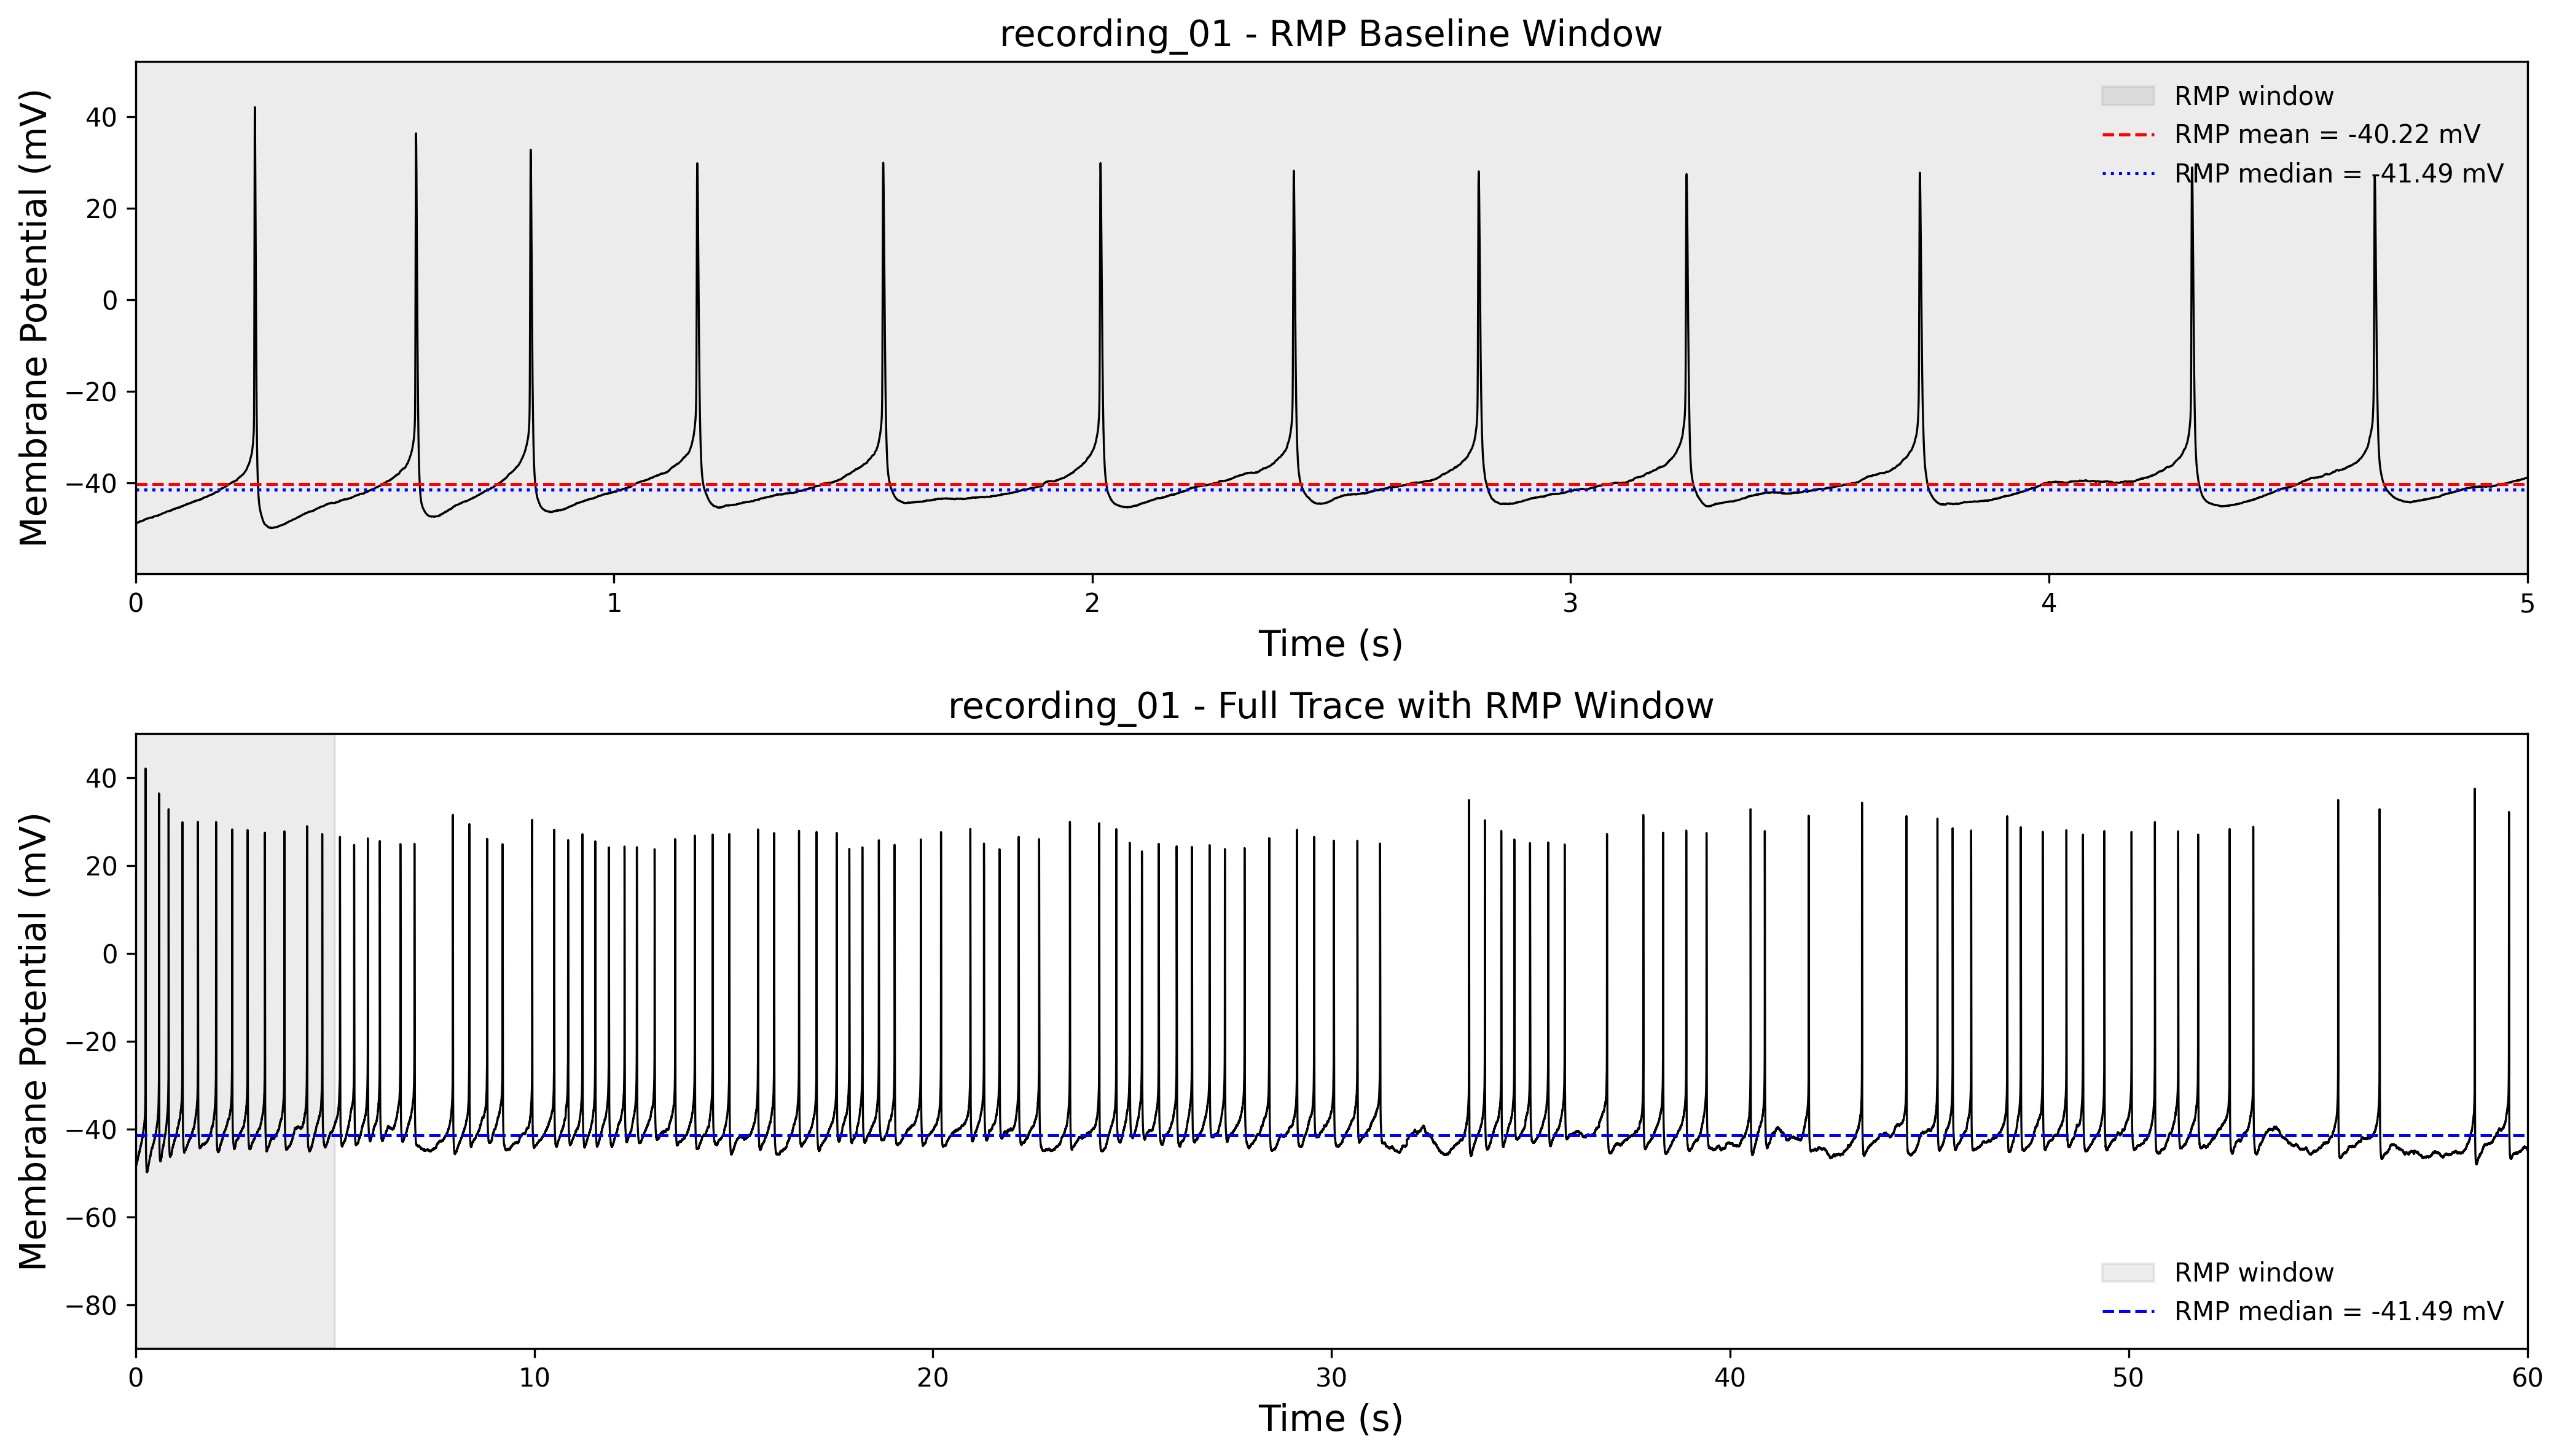

Representative QC results:
Recording: recording_01
RMP mean: -40.22 mV
RMP median: -41.49 mV
Baseline SD/noise: 7.50 mV


In [9]:
# ============================================================
# REPRESENTATIVE QUALITY-CONTROL VISUALIZATION
# Two-panel version: baseline window + full trace
# ============================================================

# Private file used only to generate the representative QC plot.
# Before uploading to GitHub, this will be changed to "recording_01.asc".
PRIVATE_QC_FILE = "recording_01.asc"

# Public anonymized name displayed in the figure
REPRESENTATIVE_RECORDING_NAME = "recording_01"

qc_file_path = os.path.join(BASE_PATH, PRIVATE_QC_FILE)

# Load data
data = load_heka_ascii_voltage(qc_file_path)

time_s = data["Time_s"].values
voltage_mV = data["Voltage_mV"].values

# Baseline window
window_mask = (time_s >= 0) & (time_s <= BASELINE_WINDOW_S)
baseline_voltage = voltage_mV[window_mask]

# Calculate RMP values
rmp_mean_mV = np.mean(baseline_voltage)
rmp_median_mV = np.median(baseline_voltage)
baseline_sd_mV = np.std(baseline_voltage)

# ============================================================
# Two-panel QC figure
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8),
    dpi=300,
    gridspec_kw={"height_ratios": [1, 1.2]}
)

# ------------------------------------------------------------
# Top panel: baseline window
# ------------------------------------------------------------

axes[0].plot(
    time_s[window_mask],
    voltage_mV[window_mask],
    color="black",
    linewidth=0.8
)

axes[0].axvspan(
    0,
    BASELINE_WINDOW_S,
    color="gray",
    alpha=0.15,
    label="RMP window"
)

axes[0].axhline(
    rmp_mean_mV,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label=f"RMP mean = {rmp_mean_mV:.2f} mV"
)

axes[0].axhline(
    rmp_median_mV,
    color="blue",
    linestyle=":",
    linewidth=1.2,
    label=f"RMP median = {rmp_median_mV:.2f} mV"
)

axes[0].set_xlim(0, BASELINE_WINDOW_S)
axes[0].set_ylim(np.min(baseline_voltage) - 10, np.max(baseline_voltage) + 10)

axes[0].set_title(
    f"{REPRESENTATIVE_RECORDING_NAME} - RMP Baseline Window",
    fontsize=14
)

axes[0].set_xlabel("Time (s)", fontsize=14)
axes[0].set_ylabel("Membrane Potential (mV)", fontsize=14)
axes[0].legend(frameon=False, loc="upper right")


# ------------------------------------------------------------
# Bottom panel: full trace
# ------------------------------------------------------------

axes[1].plot(
    time_s,
    voltage_mV,
    color="black",
    linewidth=0.8
)

axes[1].axvspan(
    0,
    BASELINE_WINDOW_S,
    color="gray",
    alpha=0.15,
    label="RMP window"
)

axes[1].axhline(
    rmp_median_mV,
    color="blue",
    linestyle="--",
    linewidth=1.2,
    label=f"RMP median = {rmp_median_mV:.2f} mV"
)

axes[1].set_xlim(0, 60)
axes[1].set_ylim(Y_MIN, Y_MAX)

axes[1].set_title(
    f"{REPRESENTATIVE_RECORDING_NAME} - Full Trace with RMP Window",
    fontsize=14
)

axes[1].set_xlabel("Time (s)", fontsize=14)
axes[1].set_ylabel("Membrane Potential (mV)", fontsize=14)
axes[1].legend(frameon=False, loc="lower right")

plt.tight_layout()

plt.savefig(
    f"{REPRESENTATIVE_RECORDING_NAME}_rmp_quality_control.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    f"{REPRESENTATIVE_RECORDING_NAME}_rmp_quality_control.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("Representative QC results:")
print(f"Recording: {REPRESENTATIVE_RECORDING_NAME}")
print(f"RMP mean: {rmp_mean_mV:.2f} mV")
print(f"RMP median: {rmp_median_mV:.2f} mV")
print(f"Baseline SD/noise: {baseline_sd_mV:.2f} mV")